In [16]:
from __future__ import annotations

import csv
import logging
import math
import sys
import time
import warnings
import optuna

from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import typer

from torch.amp import GradScaler, autocast
from torch.amp.autocast_mode import autocast
from torch.optim import Adam
from torch.utils.data import DataLoader as TorchDataLoader
from torch_geometric.data import Data, Dataset as PyGDataset
from torch_geometric.loader import DataLoader, DataLoader as PyGDataLoader
from tqdm import tqdm

from qqe.GNN.physics_aware_NN import QuantumCircuitGraphDataset
from qqe.experiments.plotting import plot_training_curves
from qqe.GNN.training.datasets import build_loaders, build_loaders_NN
from qqe.GNN.training.train import build_loss, train_model
from qqe.GNN.training.train_config import TrainConfig
from qqe.GNN.training.utils import (
    collect_files_path,
    evaluate_loss,
    unpack_supervised_batch,
)
from qqe.utils import configure_logger

logger = logging.getLogger(__name__)

_AMP_DEVICE_TYPE = "cuda" if torch.cuda.is_available() else "cpu"

## Model definitions

In [17]:
GNN_HIDDEN = 32
GNN_HEADS = 2
GLOBAL_HIDDEN = 32
REG_HIDDEN = 32
NUM_LAYERS = 2
dropout_rate = 0.15


class GlobalMLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 64, dropout_rate: float = 0.0):
        super().__init__()
        dr = float(dropout_rate) if dropout_rate is not None else 0.0
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
        )

    def forward(self, g: torch.Tensor) -> torch.Tensor:
        return self.net(g)


class Regressor(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 128, dropout_rate: float = 0.0):
        super().__init__()
        dr = float(dropout_rate) if dropout_rate is not None else 0.0
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        return self.net(h)

def _get_activation(activation: str) -> nn.Module:
    if activation == "relu":
        return nn.ReLU()
    elif activation == "elu":
        return nn.ELU()
    else:
        raise ValueError(f"Unsupported activation function: {activation}")


class NN(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 64, dropout_rate: float = 0.0):
        super().__init__()
        dr = float(dropout_rate) if dropout_rate is not None else 0.0
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, g: torch.Tensor) -> torch.Tensor:
        return self.net(g)

class GNN(nn.Module):
    def __init__(
        self,
        node_in_dim: int = 23,
        gnn_hidden: int = GNN_HIDDEN,
        gnn_heads: int = GNN_HEADS,
        global_in_dim: int = 8,
        global_hidden: int = GLOBAL_HIDDEN,
        reg_hidden: int = REG_HIDDEN,
        num_layers: int = NUM_LAYERS,
        dropout_rate: float = 0.1,
    ):
        super().__init__()
        from torch_geometric.nn import TransformerConv, global_mean_pool

        self.global_mean_pool = global_mean_pool

        if num_layers < 1:
            raise ValueError("num_layers must be >= 1")
        self.num_layers = int(num_layers)
        self.gnn_hidden = gnn_hidden
        self.gnn_heads = gnn_heads
        self.dropout_rate = float(dropout_rate) if dropout_rate is not None else 0.0

        conv_layers = [
            TransformerConv(
                node_in_dim, gnn_hidden, heads=gnn_heads, dropout=self.dropout_rate, beta=False
            ),
        ]
        conv_layers.extend(
            [
                TransformerConv(
                    gnn_hidden * gnn_heads,
                    gnn_hidden,
                    heads=gnn_heads,
                    dropout=self.dropout_rate,
                    beta=False,
                )
                for _ in range(1, self.num_layers)
            ],
        )
        self.conv_layers = nn.ModuleList(conv_layers)
        self.global_mlp = GlobalMLP(global_in_dim, global_hidden, dropout_rate=self.dropout_rate)
        concat_dim = gnn_hidden * gnn_heads + global_hidden
        self.regressor = Regressor(concat_dim, reg_hidden, dropout_rate=self.dropout_rate)


    def forward(self, data) -> torch.Tensor:
        x, edge_index = data.x, data.edge_index
        batch = getattr(data, "batch", None)
        if batch is None:
            batch = x.new_zeros(x.size(0), dtype=torch.long)
        num_graphs = int(batch.max().item() + 1) if batch.numel() else 1

        # GNN branch
        if x is None or x.size(0) == 0:
            x_pool = x.new_zeros((num_graphs, self.gnn_hidden * self.gnn_heads), dtype=torch.float32)
        else:
            with autocast(_AMP_DEVICE_TYPE, enabled=False):
                h = x.float()
                for conv in self.conv_layers:
                    h = F.relu(conv(h, edge_index))
                    if self.dropout_rate:
                        h = F.dropout(h, p=self.dropout_rate, training=self.training)
                x_pool = self.global_mean_pool(h, batch)

        # Global branch
        g = data.global_features
        if g.dim() == 1:
            if g.numel() % num_graphs != 0:
                raise RuntimeError(
                    f"Inconsistent global_features in batch: total={g.numel()}, "
                    f"num_graphs={num_graphs}. Expected fixed per-graph feature length."
                )
            g = g.view(num_graphs, -1)
        elif g.dim() == 2 and g.size(0) == num_graphs:
            pass
        else:
            g = g.reshape(num_graphs, -1)
        g_feat = self.global_mlp(g.float())

        # Combine
        out = self.regressor(torch.cat([x_pool, g_feat], dim=-1))
        return out.view(-1)

## Training helpers

In [18]:
def _resolve_model_save_path(base_path: str, allow_overwrite: bool = False) -> str:
    """Return a non-colliding checkpoint path unless overwrite is explicitly allowed."""
    path = Path(base_path)
    if allow_overwrite or not path.exists():
        return str(path)

    stem = path.stem
    suffix = path.suffix
    parent = path.parent
    counter = 1

    while True:
        candidate = parent / f"{stem}_v{counter}{suffix}"
        if not candidate.exists():
            print(
                "Model checkpoint already exists at %s. Saving to %s instead.",
                path,
                candidate,
            )
            return str(candidate)
        counter += 1

In [19]:
def _amp_device_type() -> str:
    return "cuda" if torch.cuda.is_available() else "cpu"

def build_loss(loss_type: str, huber_delta: float = 1.0) -> nn.Module:
    loss_type = loss_type.lower()
    if loss_type == "mse":
        return nn.MSELoss()
    if loss_type == "l1":
        return nn.L1Loss()
    if loss_type == "huber":
        return nn.HuberLoss(delta=huber_delta)
    raise ValueError(f"Unsupported loss type: {loss_type}")


@dataclass
class TrainHistory:
    train_loss: list[float]
    val_loss: list[float]
    lr: list[float]

def _run_train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    scaler: GradScaler,
    device: torch.device,
    *,
    use_amp: bool = True,
    grad_clip: float | None = 5.0,
    epoch_idx: int = 1,
    num_epochs: int = 1,
    show_progress: bool = True,
    log_every_n_batches: int = 20,
    heartbeat_secs: float = 60.0,
) -> tuple[float, float]:
    model.train()
    amp_device = _amp_device_type()

    total_loss = 0.0
    total_graphs = 0
    batch_count = 0

    start_time = time.time()
    last_heartbeat = start_time

    train_iter = tqdm(
        loader,
        desc=f"Epoch {epoch_idx}/{num_epochs}",
        leave=False,
        disable=not show_progress,
        file=sys.stdout,
    )

    for batch in train_iter:
        model_input, y, batch_size = unpack_supervised_batch(batch, device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(
            device_type=amp_device,
            enabled=(use_amp and device.type == "cuda"),
        ):
            pred = model(model_input).view(-1).float()
            mask = torch.isfinite(y)
            if mask.sum() == 0:
                continue
            loss = loss_fn(pred[mask], y[mask])

        if not torch.isfinite(loss):
            logger.warning("Skipping batch with non-finite loss.")
            continue

        scaler.scale(loss).backward()

        if grad_clip is not None and grad_clip > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(grad_clip))

        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.item()) * batch_size
        total_graphs += batch_size
        batch_count += 1

        running_loss = total_loss / max(1, total_graphs)

        if show_progress:
            train_iter.set_postfix(
                {
                    "loss": f"{running_loss:.4f}",
                    "graphs": total_graphs,
                },
            )

        if log_every_n_batches > 0 and batch_count % log_every_n_batches == 0:
            elapsed = time.time() - start_time
            batches_per_sec = batch_count / max(elapsed, 1e-3)
            remaining_batches = len(loader) - batch_count
            eta_secs = remaining_batches / max(batches_per_sec, 1e-3)

            logger.debug(
                f"Epoch {epoch_idx} batch {batch_count}/{len(loader)} | "
                f"loss {running_loss:.6f} | elapsed {elapsed:.1f}s | "
                f"ETA {eta_secs:.1f}s | {batches_per_sec:.2f} batch/s",
            )

        if heartbeat_secs > 0:
            now = time.time()
            if now - last_heartbeat >= heartbeat_secs:
                elapsed = time.time() - start_time
                print(
                    f"[Heartbeat] Epoch {epoch_idx} batch {batch_count}/{len(loader)} | "
                    f"loss {running_loss:.6f} | elapsed {elapsed:.1f}s | graphs {total_graphs}",
                )
                last_heartbeat = now

    epoch_loss = total_loss / max(1, total_graphs)
    elapsed = time.time() - start_time
    return epoch_loss, elapsed


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    device: str | None = None,
    loss_type: str = "huber",   # "mse" | "huber" | "l1"
    huber_delta: float = 1.0,
    grad_clip: float | None = 5.0,
    early_stopping_patience: int = 15,
    early_stopping_min_delta: float = 0.0,
    use_amp: bool = True,
    scheduler: str = "none",    # "none" | "plateau"
    show_progress: bool = True,
    show_val_progress: bool = False,
    log_every_n_batches: int = 20,
    heartbeat_secs: float = 60.0,
    epoch_time_warning_secs: float = 300.0,
) -> tuple[nn.Module, TrainHistory, torch.device]:
    dev = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    print(f"Using device: {dev}")
    model = model.to(dev)

    loss_fn = build_loss(loss_type=loss_type, huber_delta=huber_delta)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    if scheduler == "plateau":
        lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=5,
        )
    elif scheduler == "none":
        lr_scheduler = None
    else:
        raise ValueError("scheduler must be 'none' or 'plateau'")

    scaler = GradScaler(
        device=_amp_device_type(),
        enabled=(use_amp and dev.type == "cuda"),
    )

    history = TrainHistory(train_loss=[], val_loss=[], lr=[])

    best_val_loss = float("inf")
    best_state_dict = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        epoch_start_time = time.time()
        print(f"-------- EPOCH {epoch:03d} --------")

        train_loss, train_time = _run_train_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            scaler=scaler,
            device=dev,
            use_amp=use_amp,
            grad_clip=grad_clip,
            epoch_idx=epoch,
            num_epochs=epochs,
            show_progress=show_progress,
            log_every_n_batches=log_every_n_batches,
            heartbeat_secs=heartbeat_secs,
        )

        print(f"Training complete ({train_time:.1f}s) | running validation...")

        val_start_time = time.time()
        val_loss = evaluate_loss(
            model=model,
            loader=val_loader,
            device=dev,
            loss_fn=loss_fn,
            use_amp=use_amp,
            show_progress=show_val_progress,
        )
        val_time = time.time() - val_start_time

        if lr_scheduler is not None:
            lr_scheduler.step(val_loss)

        current_lr = float(optimizer.param_groups[0]["lr"])
        history.train_loss.append(float(train_loss))
        history.val_loss.append(float(val_loss))
        history.lr.append(current_lr)

        epoch_time = time.time() - epoch_start_time

        print(
            f"Losses | train {train_loss:.6f} | val {val_loss:.6f} | "
            f"lr {current_lr:.2e} | time train={train_time:.1f}s "
            f"val={val_time:.1f}s total={epoch_time:.1f}s",
        )

        if epoch_time_warning_secs > 0 and epoch_time > epoch_time_warning_secs:
            logger.warning(
                f"Epoch {epoch} took {epoch_time:.1f}s "
                f"(>{epoch_time_warning_secs:.0f}s threshold).",
            )

        improved = val_loss + early_stopping_min_delta < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
            logger.debug(f"New best validation loss: {best_val_loss:.6f}")
        else:
            bad_epochs += 1
            logger.debug(
                f"No improvement: patience {bad_epochs}/{early_stopping_patience}",
            )
            if bad_epochs >= early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch:03d} | "
                    f"best val {best_val_loss:.6f} | "
                    f"patience exhausted ({bad_epochs}/{early_stopping_patience})",
                )
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history, dev

In [20]:
def run_training(
    cfg: TrainConfig,
    model_hparams: dict | None = None,
    train_hparams: dict | None = None,
):
    family_filter = cfg.family if cfg.training_mode == "per_family" else None
    family_projection = cfg.family if cfg.training_mode == "per_family" else None

    VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
    if cfg.training_mode == "per_family" and cfg.family not in VALID_FAMILIES:
        raise ValueError(
            f"Invalid family: {cfg.family}. Must be one of {sorted(VALID_FAMILIES)}",
        )
    if cfg.training_mode not in {"global", "per_family"}:
        raise ValueError("training_mode must be 'global' or 'per_family'")
    if cfg.training_mode == "per_family" and cfg.family is None:
        raise ValueError("family must be provided when training_mode='per_family'")

    data_paths = collect_files_path("../outputs/data", family=family_filter)
    if not data_paths:
        raise RuntimeError("No data paths found.")

    train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset = (
        build_loaders(
            data_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family_projection,
        )
    )

    default_model_hparams = {
        "gnn_hidden": 32,
        "gnn_heads": 8,
        "global_hidden": 16,
        "reg_hidden": 16,
        "num_layers": 3,
        "dropout_rate": 0.1,
    }
    if model_hparams:
        default_model_hparams.update(model_hparams)

    model = GNN(
        node_in_dim=node_in_dim,
        global_in_dim=global_in_dim,
        gnn_hidden=default_model_hparams["gnn_hidden"],
        gnn_heads=default_model_hparams["gnn_heads"],
        global_hidden=default_model_hparams["global_hidden"],
        reg_hidden=default_model_hparams["reg_hidden"],
        num_layers=default_model_hparams["num_layers"],
        dropout_rate=default_model_hparams["dropout_rate"],
    )

    default_train_hparams = {
        "weight_decay": 0.0,
        "grad_clip": 5.0,
        "early_stopping_patience": 15,
        "early_stopping_min_delta": 0.0,
    }
    if train_hparams:
        default_train_hparams.update(train_hparams)

    model, hist, dev = train_model(
        model,
        train_loader,
        val_loader,
        epochs=cfg.epochs,
        lr=cfg.lr,
        loss_type=cfg.loss_type,
        scheduler="plateau",
        show_progress=cfg.show_progress,
        show_val_progress=cfg.show_val_progress,
        log_every_n_batches=cfg.log_batch_loss_every,
        heartbeat_secs=cfg.heartbeat,
        epoch_time_warning_secs=cfg.epoch_warning,
        weight_decay=default_train_hparams["weight_decay"],
        grad_clip=default_train_hparams["grad_clip"],
        early_stopping_patience=default_train_hparams["early_stopping_patience"],
        early_stopping_min_delta=default_train_hparams["early_stopping_min_delta"],
    )

    loss_fn = build_loss(cfg.loss_type, huber_delta=1.0)
    test_loss = evaluate_loss(
        model,
        test_loader,
        dev,
        loss_fn,
        use_amp=True,
        show_progress=True,
    )

    return (
        model,
        hist,
        test_loss,
        node_in_dim,
        global_in_dim,
        base_dataset,
        default_model_hparams,
    )

In [21]:
def run_training_NN(
    cfg: TrainConfig,
    model_type: str | None = None,
    model_params: dict | None = None,
):
    family_filter = cfg.family if cfg.training_mode == "per_family" else None
    family_projection = cfg.family if cfg.training_mode == "per_family" else None

    VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
    if cfg.training_mode == "per_family" and cfg.family not in VALID_FAMILIES:
        raise ValueError(
            f"Invalid family: {cfg.family}. Must be one of {sorted(VALID_FAMILIES)}",
        )
    if cfg.training_mode not in {"global", "per_family"}:
        raise ValueError("training_mode must be 'global' or 'per_family'")
    if cfg.training_mode == "per_family" and cfg.family is None:
        raise ValueError("family must be provided when training_mode='per_family'")

    data_paths = collect_files_path("../outputs/data", family=family_filter)
    if not data_paths:
        raise RuntimeError("No data paths found.")

    train_loader, val_loader, test_loader, global_in_dim, base_dataset = build_loaders_NN(
        data_paths,
        batch_size=cfg.batch_size,
        seed=cfg.seed,
        train_split=cfg.train_split,
        val_split=cfg.val_split,
        global_feature_variant=cfg.global_feature_variant,
        node_feature_variant=cfg.node_feature_backend_variant,
        family_projection=family_projection,
    )
    if model_type == "nn":
        pass
    elif model_type == "MLP":
        model = GlobalMLP(
            in_dim = global_in_dim,
            hidden_dim = model_params.get("hidden_dim", 128) if model_params else 64,
            dropout_rate = model_params.get("dropout_rate", 0.0) if model_params else 0.0,
        )
    elif model_type == "regressor":
        model = Regressor(
            in_dim = global_in_dim,
            hidden_dim = model_params.get("hidden_dim", 128) if model_params else 64,
            dropout_rate = model_params.get("dropout_rate", 0.0) if model_params else 0.0,
        )
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

    model, hist, dev = train_model(
        model,
        train_loader,
        val_loader,
        epochs=cfg.epochs,
        lr=cfg.lr,
        loss_type=cfg.loss_type,
        scheduler="plateau",
        show_progress=cfg.show_progress,
        show_val_progress=cfg.show_val_progress,
        log_every_n_batches=cfg.log_batch_loss_every,
        heartbeat_secs=cfg.heartbeat,
        epoch_time_warning_secs=cfg.epoch_warning,
    )

    loss_fn = build_loss(cfg.loss_type, huber_delta=1.0)
    test_loss = evaluate_loss(
        model,
        test_loader,
        dev,
        loss_fn,
        use_amp=True,
        show_progress=True,
    )

    return model, hist, test_loss, global_in_dim, base_dataset

## Prediction helpers

In [ ]:
def collect_prediction_paths(dataset_root: str, family: str | None = None) -> list[str]:
    root = Path(dataset_root)
    pred_root = root / "predictions"

    if family is not None:
        paths = sorted((pred_root / family).glob("*.pt"))
    else:
        paths = []
        if pred_root.exists():
            for subdir in sorted(pred_root.iterdir()):
                if subdir.is_dir():
                    paths.extend(sorted(subdir.glob("*.pt")))

    return [str(p.resolve()) for p in paths]


def checkpoint_path(model_kind: str, training_scope: str, family: str | None = None, loss_type: str = "mse") -> Path:
    if model_kind not in {"gnn", "nn", "regressor"}:
        raise ValueError("model_kind must be 'gnn', 'nn', or 'regressor'")
    if training_scope not in {"global", "family"}:
        raise ValueError("training_scope must be 'global' or 'family'")

    if training_scope == "family":
        if family is None:
            raise ValueError("family must be provided when training_scope='family'")
        return Path(f"models/{model_kind}_model_{loss_type}_{family}.pt")

    return Path(f"models/{model_kind}_model_{loss_type}_global.pt")


def load_checkpoint(path: str | Path) -> tuple[dict[str, Any], dict[str, Any], dict[str, Any]]:
    payload = torch.load(path, map_location="cpu", weights_only=False)

    if not isinstance(payload, dict):
        raise RuntimeError("Checkpoint must be a dict.")

    if "model_state_dict" in payload:
        state_dict = payload["model_state_dict"]
        model_config = payload.get("model_config", {}) or {}
        feature_config = payload.get("feature_config", {}) or {}
    else:
        # older raw state_dict format
        state_dict = payload
        model_config = {}
        feature_config = {}

    return state_dict, model_config, feature_config


def build_model(model_kind: str, model_config: dict[str, Any]) -> torch.nn.Module:
    if model_kind == "gnn":
        return GNN(
            node_in_dim=int(model_config["node_in_dim"]),
            global_in_dim=int(model_config["global_in_dim"]),
            gnn_hidden=int(model_config.get("gnn_hidden", 32)),
            gnn_heads=int(model_config.get("gnn_heads", 8)),
            global_hidden=int(model_config.get("global_hidden", 16)),
            reg_hidden=int(model_config.get("reg_hidden", 16)),
            num_layers=int(model_config.get("num_layers", 5)),
            dropout_rate=float(model_config.get("dropout_rate", 0.1)),
        )

    if model_kind == "nn":
        return GlobalMLP(
            in_dim=int(model_config["global_in_dim"]),
            hidden_dim=int(model_config.get("hidden_dim", 128)),
        )

    if model_kind == "regressor":
        return Regressor(
            in_dim=int(model_config["global_in_dim"]),
            hidden_dim=int(model_config.get("hidden_dim", 128)),
        )

    raise ValueError(f"Unsupported model_kind: {model_kind}")


In [71]:
class PredictionGraphWrapper:
    def __init__(
        self,
        dataset,
        target_node_dim: int | None = None,
        target_global_dim: int | None = None,
    ):
        self.dataset = dataset
        self.target_node_dim = target_node_dim
        self.target_global_dim = target_global_dim

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int):
        data = self.dataset[idx].clone()

        if self.target_node_dim is not None:
            cur = int(data.x.shape[1])
            if cur < self.target_node_dim:
                data.x = F.pad(data.x, (0, self.target_node_dim - cur))
            elif cur > self.target_node_dim:
                data.x = data.x[:, : self.target_node_dim]

        if hasattr(data, "global_features"):
            g = data.global_features
            if g.dim() > 1:
                g = g.view(-1)

            if self.target_global_dim is not None:
                cur = int(g.shape[0])
                if cur < self.target_global_dim:
                    g = F.pad(g, (0, self.target_global_dim - cur))
                elif cur > self.target_global_dim:
                    g = g[: self.target_global_dim]

            data.global_features = g

        return data


class PredictionTensorWrapper:
    def __init__(self, dataset, target_global_dim: int | None = None):
        self.dataset = dataset
        self.target_global_dim = target_global_dim

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int):
        data = self.dataset[idx]
        g = data.global_features
        if not torch.is_tensor(g):
            g = torch.as_tensor(g, dtype=torch.float32)
        g = g.flatten().to(torch.float32)

        if self.target_global_dim is not None:
            cur = int(g.shape[0])
            if cur < self.target_global_dim:
                g = F.pad(g, (0, self.target_global_dim - cur))
            elif cur > self.target_global_dim:
                g = g[: self.target_global_dim]

        meta = getattr(data, "meta", {}) or {}
        target = extract_target_value(data)
        return g, meta, target


def build_prediction_dataset(
    pt_paths: list[str],
    *,
    global_feature_variant: str,
    node_feature_backend_variant: str | None,
    fixed_all_gate_keys: list[str] | None,
):
    return QuantumCircuitGraphDataset(
        root="qqe/cache/prediction_cache",
        pt_paths=pt_paths,
        global_feature_variant=global_feature_variant,
        node_feature_backend_variant=node_feature_backend_variant,
        fixed_all_gate_keys=fixed_all_gate_keys,
    )


def build_loader(
    model_kind: str,
    dataset,
    *,
    batch_size: int,
    target_node_dim: int | None,
    target_global_dim: int | None,
):
    if model_kind == "gnn":
        wrapped = PredictionGraphWrapper(
            dataset,
            target_node_dim=target_node_dim,
            target_global_dim=target_global_dim,
        )
        return PyGDataLoader(
            wrapped,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )

    if model_kind == "nn":
        wrapped = PredictionTensorWrapper(dataset, target_global_dim=target_global_dim)

        def collate_fn(batch):
            xs, metas, targets = zip(*batch)
            return torch.stack(xs, dim=0), list(metas), list(targets)

        return TorchDataLoader(
            wrapped,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
            collate_fn=collate_fn,
        )

    raise ValueError(f"Unsupported model_kind: {model_kind}")

In [72]:
def extract_target_value(sample: Any) -> float | None:
    y = getattr(sample, "y", None)
    if y is None:
        return None

    if torch.is_tensor(y):
        if y.numel() == 0:
            return None
        value = float(y.flatten()[0].item())
    else:
        value = float(y)

    if not np.isfinite(value):
        return None

    return value

@torch.no_grad()
def predict(
    model: torch.nn.Module,
    loader,
    *,
    model_kind: str,
    device: torch.device,
    show_progress: bool = True,
) -> list[dict[str, Any]]:
    model.eval()
    rows: list[dict[str, Any]] = []
    total_batches = len(loader) if hasattr(loader, "__len__") else None

    if model_kind == "gnn":
        for batch in tqdm(
            loader,
            total=total_batches,
            desc="Predicting (gnn)",
            unit="batch",
            disable=not show_progress,
        ):
            samples = batch.to_data_list()
            batch = batch.to(device)
            preds = model(batch).view(-1).cpu().tolist()

            for sample, pred in zip(samples, preds):
                meta = getattr(sample, "meta", {}) or {}
                target = extract_target_value(sample)
                rows.append(
                    {
                        "cid": meta.get("cid"),
                        "family": meta.get("family"),
                        "seed": meta.get("seed"),
                        "n_qubits": meta.get("n_qubits"),
                        "n_layers": meta.get("n_layers"),
                        "target": target,
                        "prediction": float(pred),
                        "error": abs(float(pred - target)) if target is not None else None,
                    },
                )
        return rows

    if model_kind == "nn":
        for x, metas, targets in tqdm(
            loader,
            total=total_batches,
            desc="Predicting (nn)",
            unit="batch",
            disable=not show_progress,
        ):
            x = x.to(device)
            preds = model(x).view(-1).cpu().tolist()

            for meta, pred, target in zip(metas, preds, targets):
                rows.append(
                    {
                        "cid": meta.get("cid"),
                        "family": meta.get("family"),
                        "seed": int(meta.get("seed")),
                        "n_qubits": int(meta.get("n_qubits")),
                        "n_layers": int(meta.get("n_layers")),
                        "target": target,
                        "prediction": float(pred),
                        "error": abs(float(pred - target)) if target is not None else None,
                    },
                )
        return rows

    raise ValueError(f"Unsupported model_kind: {model_kind}")


In [73]:
def save_predictions_csv(rows: list[dict[str, Any]], path: str | Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    fieldnames = ["cid", "family", "seed", "n_qubits", "n_layers", "target", "prediction", "error"]
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    return path


def aggregate_mean_std(
    rows: list[dict[str, Any]],
    *,
    x_key: str,
    fixed_key: str | None = None,
    fixed_value: int | None = None,
) -> list[dict[str, Any]]:
    filtered = rows
    if fixed_key is not None and fixed_value is not None:
        filtered = [r for r in rows if int(r[fixed_key]) == int(fixed_value)]

    groups: dict[int, list[float]] = {}
    for r in filtered:
        x = int(r[x_key])
        groups.setdefault(x, []).append(float(r["prediction"]))

    out = []
    for x in sorted(groups):
        vals = np.asarray(groups[x], dtype=float)
        out.append(
            {
                x_key: x,
                "mean": float(vals.mean()),
                "std": float(vals.std(ddof=0)),
                "n": len(vals),
            },
        )
    return out


# =========================================================
# Plotting
# =========================================================

def plot_fixed_layers_vary_qubits(
    rows: list[dict[str, Any]],
    *,
    n_layers: int,
    output_path: str | Path | None = None,
    split_by_family: bool = True,
):
    filtered = [r for r in rows if int(r["n_layers"]) == int(n_layers)]
    if not filtered:
        print("No predictions found for n_layers=%s", n_layers)
        return

    plt.figure(figsize=(8, 5))

    if split_by_family:
        families = sorted({str(r.get("family", "unknown")) for r in filtered})
        for family in families:
            family_rows = [r for r in filtered if str(r.get("family", "unknown")) == family]

            groups: dict[int, list[float]] = {}
            for r in family_rows:
                q = int(r["n_qubits"])
                groups.setdefault(q, []).append(float(r["prediction"]))

            x = sorted(groups.keys())
            y = [np.mean(groups[q]) for q in x]
            yerr = [np.std(groups[q], ddof=0) for q in x]

            plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3, label=family)

        plt.legend(title="family")
        plt.title(f"Predicted SRE vs qubits (n_layers={n_layers})")
    else:
        groups: dict[int, list[float]] = {}
        for r in filtered:
            q = int(r["n_qubits"])
            groups.setdefault(q, []).append(float(r["prediction"]))

        x = sorted(groups.keys())
        y = [np.mean(groups[q]) for q in x]
        yerr = [np.std(groups[q], ddof=0) for q in x]

        plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3)
        plt.title(f"Predicted SRE vs qubits (n_layers={n_layers})")

    plt.xlabel("Number of qubits")
    plt.ylabel("Predicted SRE")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=180)
        plt.close()
    else:
        plt.show()

def plot_fixed_qubits_vary_layers(
    rows: list[dict[str, Any]],
    *,
    n_qubits: int,
    output_path: str | Path | None = None,
    split_by_family: bool = True,
):
    filtered = [r for r in rows if int(r["n_qubits"]) == int(n_qubits)]
    if not filtered:
        print("No predictions found for n_qubits=%s", n_qubits)
        return

    plt.figure(figsize=(8, 5))

    if split_by_family:
        families = sorted({str(r.get("family", "unknown")) for r in filtered})
        for family in families:
            family_rows = [r for r in filtered if str(r.get("family", "unknown")) == family]

            groups: dict[int, list[float]] = {}
            for r in family_rows:
                L = int(r["n_layers"])
                groups.setdefault(L, []).append(float(r["prediction"]))

            x = sorted(groups.keys())
            y = [np.mean(groups[L]) for L in x]
            yerr = [np.std(groups[L], ddof=0) for L in x]

            plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3, label=family)

        plt.legend(title="family")
        plt.title(f"Predicted SRE vs layers (n_qubits={n_qubits})")
    else:
        groups: dict[int, list[float]] = {}
        for r in filtered:
            L = int(r["n_layers"])
            groups.setdefault(L, []).append(float(r["prediction"]))

        x = sorted(groups.keys())
        y = [np.mean(groups[L]) for L in x]
        yerr = [np.std(groups[L], ddof=0) for L in x]

        plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3)
        plt.title(f"Predicted SRE vs layers (n_qubits={n_qubits})")

    plt.xlabel("Number of layers")
    plt.ylabel("Predicted SRE")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=180)
        plt.close()
    else:
        plt.show()

## Training

In [26]:
MODEL_REGISTRY = {
    "gnn": {
        "loader": "gnn",
        "constructor": GNN,
        "uses_nodes": True,
    },
    "nn": {
        "loader": "nn",
        "constructor": NN,
        "uses_nodes": False,
    },
    "regressor": {
        "loader": "nn",
        "constructor": Regressor,
        "uses_nodes": False,
    },
}

In [78]:
def train(
    *,
    model_type: str = "gnn",
    epochs: int = 150,
    lr: float = 1e-3,
    loss_type: str = "huber",   # "mse" | "huber"
    batch_size: int = 32,
    training_mode: str = "global",  # "global" | "per_family"
    family: str | None = None,  # required if training_mode == "per_family"
    target: str = "sre",
    model_hparams: dict[str, int | float] | None = None,
    train_hparams: dict[str, int | float] | None = None,
    training_data_dir: str = "../outputs/data",
    allow_overwrite: bool = False,
    save_checkpoint: bool = True,
    save_fig: bool = True,
    show_progress: bool = True,
    show_val_progress: bool = False,
    log_every_n_batches: int = 10,
    heartbeat_secs: float = 60.0,
    epoch_time_warning_secs: float = 500.0,
):
    VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
    if model_type not in MODEL_REGISTRY:
        raise ValueError(f"Unsupported model_type: {model_type}. Must be one of {sorted(MODEL_REGISTRY)}")

    if training_mode not in {"global", "per_family"}:
        raise ValueError("training_mode must be 'global' or 'per_family'")

    if training_mode == "per_family":
        if family is None:
            raise ValueError("family must be provided when training_mode='per_family'")
        if family not in VALID_FAMILIES:
            raise ValueError(
                f"Invalid family: {family}. Must be one of {sorted(VALID_FAMILIES)}"
            )

    print(f"Starting training | model_type={model_type} | training_mode={training_mode} | family={family} | loss_type={loss_type}")
    cfg = TrainConfig(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        show_progress=show_progress,
        show_val_progress=show_val_progress,
        log_batch_loss_every=log_every_n_batches,
        heartbeat=heartbeat_secs,
        epoch_warning=epoch_time_warning_secs,
    )
    print("Training configuration done.")

    model_hparams = {} if model_hparams is None else dict(model_hparams)
    train_hparams = {} if train_hparams is None else dict(train_hparams)

    family_filter = family if training_mode == "per_family" else None
    family_projection = family if training_mode == "per_family" else None

    print("Collecting data paths...")
    data_paths = collect_files_path(training_data_dir, family=family_filter)
    if not data_paths:
        raise RuntimeError("No data paths found.")
    print(f"Found {len(data_paths)} data paths.")
    print("Data paths collected.")

    spec = MODEL_REGISTRY[model_type]
    print(f"Building loaders and model for model_type={model_type}...")
    if spec["loader"] == "gnn":
        (
            train_loader,
            val_loader,
            test_loader,
            node_in_dim,
            global_in_dim,
            base_dataset,
        ) = build_loaders(
            data_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family_projection,
        )

        model = GNN(
            node_in_dim=node_in_dim,
            global_in_dim=global_in_dim,
            gnn_hidden=model_hparams.get("gnn_hidden", 32),
            gnn_heads=model_hparams.get("gnn_heads", 4),
            global_hidden=model_hparams.get("global_hidden", 32),
            reg_hidden=model_hparams.get("reg_hidden", 64),
            num_layers=model_hparams.get("num_layers", 3),
            dropout_rate=model_hparams.get("dropout_rate", 0.0),
        )

    else:
        (
            train_loader,
            val_loader,
            test_loader,
            global_in_dim,
            base_dataset,
        ) = build_loaders_NN(
            data_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family_projection,
        )
        node_in_dim = global_in_dim
        model_hparams = {
            "gnn_hidden": None,
            "gnn_heads": None,
            "global_hidden": None,
            "reg_hidden": None,
            "num_layers": None,
            "dropout_rate": None,
        }

        model_cls = spec["constructor"]
        model = model_cls(
            in_dim=global_in_dim,
            hidden_dim=model_hparams.get("hidden_dim", 64),
            dropout_rate=model_hparams.get("dropout_rate", 0.0),
        )
    print("Loaders and model built.")

    print("Starting training...")
    model, hist, dev = train_model(
        model,
        train_loader,
        val_loader,
        epochs=cfg.epochs,
        lr=cfg.lr,
        loss_type=cfg.loss_type,
        scheduler="plateau",
        show_progress=cfg.show_progress,
        show_val_progress=cfg.show_val_progress,
        log_every_n_batches=cfg.log_batch_loss_every,
        heartbeat_secs=cfg.heartbeat,
        epoch_time_warning_secs=cfg.epoch_warning,
        weight_decay=train_hparams.get("weight_decay", 0.0),
        grad_clip=train_hparams.get("grad_clip", None),
        early_stopping_patience=train_hparams.get("early_stopping_patience", 30),
        early_stopping_min_delta=train_hparams.get("early_stopping_min_delta", 0.0),
    )

    loss_fn = build_loss(cfg.loss_type, huber_delta=1.0)

    test_loss = evaluate_loss(
        model,
        test_loader,
        dev,
        loss_fn,
        use_amp=True,
        show_progress=show_progress,
    )
    print("Training complete.")

    run_name = f"{model_type}_{loss_type}_{family if training_mode == 'per_family' else 'global'}"

    plot_training_curves(
        hist,
        title=f"{model_type.upper()} SRE regression",
        save_fig=save_fig,
        fig_path=f"outputs/figures/training_curves/training_curves_{run_name}.png",
    )

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "model_type": model_type,
        "model_config": {
            "node_in_dim": node_in_dim or None,
            "global_in_dim": global_in_dim,
            "gnn_hidden": model_hparams["gnn_hidden"],
            "gnn_heads": model_hparams["gnn_heads"],
            "global_hidden": model_hparams["global_hidden"],
            "reg_hidden": model_hparams["reg_hidden"],
            "num_layers": model_hparams["num_layers"],
            "dropout_rate": model_hparams["dropout_rate"],
        },
        "train_config": asdict(cfg),
        "train_hparams": train_hparams,
        "feature_config": {
            "global_feature_variant": cfg.global_feature_variant,
            "node_feature_backend_variant": cfg.node_feature_backend_variant,
            "all_gate_keys": getattr(base_dataset, "all_gate_keys", None),
            "family_projection": family_projection,
        },
        "final_metrics": {
            "test_loss": float(test_loss),
        },
        "history": hist,
    }

    if save_checkpoint:
        model_save_path = _resolve_model_save_path(
            f"../models/{run_name}.pt",
            allow_overwrite=allow_overwrite,
        )
        torch.save(checkpoint, model_save_path)
        print(f"Saved model checkpoint to {model_save_path}")

    return model, float(test_loss), hist, checkpoint

In [79]:
def create_predictions(
    model_path: str,
    model_kind: str = "gnn",
    training_scope: str = "family",
    loss_type: str = "mse",
    model_family: str | None = "random",
    data_dir: str = "../outputs/data",
    data_family: str | None = "random",
    batch_size: int = 32,
    global_feature_variant: str = "binned",
    node_feature_backend_variant: str | None = None,
    plot_layers: int = 80,
    plot_qubits: int = 8,
    split_by_family: bool = True,
    show_progress: bool = True,
):
    ckpt_path = checkpoint_path(model_kind, training_scope, model_family, loss_type)
    print("Loading checkpoint: %s", ckpt_path)
    output_csv = f"outputs/figures/predictions/{training_scope}/{model_kind}_predictions_{model_family or 'global'}.csv"

    state_dict, model_config, feature_config = load_checkpoint(model_path)
    print(f"Checkpoint loaded from {model_path}")
    print("Model config:", model_config)
    print("Feature config:", feature_config)
    print("Checkpoint loaded. Building model...")

    model = build_model(model_kind, model_config)
    model.load_state_dict(state_dict, strict=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    pt_paths = collect_prediction_paths(data_dir, data_family)
    if not pt_paths:
        raise RuntimeError("No prediction .pt files found.")

    print("Found %d prediction files", len(pt_paths))

    dataset = build_prediction_dataset(
        pt_paths,
        global_feature_variant=feature_config.get("global_feature_variant", global_feature_variant),
        node_feature_backend_variant=feature_config.get("node_feature_backend_variant", node_feature_backend_variant),
        fixed_all_gate_keys=feature_config.get("all_gate_keys"),
    )

    loader = build_loader(
        model_kind,
        dataset,
        batch_size=batch_size,
        target_node_dim=model_config.get("node_in_dim"),
        target_global_dim=model_config.get("global_in_dim"),
    )

    rows = predict(
        model,
        loader,
        model_kind=model_kind,
        device=device,
        show_progress=show_progress,
    )
    save_predictions_csv(rows, output_csv)

    print("Saved %d predictions to %s", len(rows), output_csv)

    if plot_layers is not None:
        plot_path = f"outputs/figures/predictions/{training_scope}/{model_kind}_pred_layers_{model_family or 'global'}.png"
        plot_fixed_layers_vary_qubits(
            rows,
            n_layers=plot_layers,
            output_path=plot_path,
            split_by_family=split_by_family,
        )
        print("Saved fixed-layer plot to %s", plot_path)

    if plot_qubits is not None:
        plot_path = f"outputs/figures/predictions/{training_scope}/{model_kind}_pred_qubits_{model_family or 'global'}.png"
        plot_fixed_qubits_vary_layers(
            rows,
            n_qubits=plot_qubits,
            output_path=plot_path,
            split_by_family=split_by_family,
        )
        print("Saved fixed-qubit plot to %s", plot_path)
    
    return rows

### GNN

In [45]:
default_model_hparams = {
    "gnn_hidden": 16,
    "gnn_heads": 2,
    "global_hidden": 128,
    "reg_hidden": 32,
    "num_layers": 5,
    "dropout_rate": 0.0,
}

default_train_hparams = {
    "weight_decay": 1e-3,
    "grad_clip": 5.0,
    "early_stopping_patience": 5,
    "early_stopping_min_delta": 0.0,
}

Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
Training configuration done.
Found 40000 data paths.
Data paths collected.
Building loaders and model for model_type=gnn...
Loaders and model built.
Starting training...
Using device: cuda
-------- EPOCH 001 --------
Epoch 1/15:  69%|██████▊   | 309/450 [01:00<00:29,  4.76it/s, loss=0.3694, graphs=19840][Heartbeat] Epoch 1 batch 310/450 | loss 0.369354 | elapsed 60.1s | graphs 19840
Training complete (88.0s) | running validation...                                       
Losses | train 0.277229 | val 0.053211 | lr 1.00e-03 | time train=88.0s val=8.5s total=96.5s
-------- EPOCH 002 --------
Epoch 2/15:  67%|██████▋   | 302/450 [01:00<00:31,  4.66it/s, loss=0.0538, graphs=19392][Heartbeat] Epoch 2 batch 303/450 | loss 0.053766 | elapsed 60.0s | graphs 19392
Training complete (88.4s) | running validation...                                       
Losses | train 0.049871 | val 0.053229 | lr 1.00e-

Training complete.


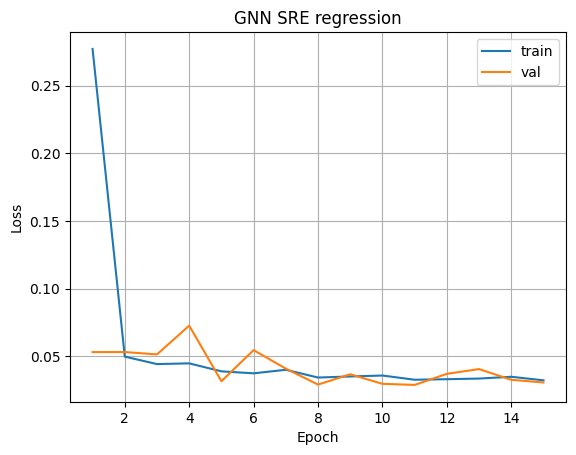

Model checkpoint already exists at %s. Saving to %s instead. ..\models\gnn_huber_random.pt ..\models\gnn_huber_random_v1.pt
Saved model checkpoint to ..\models\gnn_huber_random_v1.pt
Final test loss: 0.030082


In [46]:
model, loss, hist, chkpt = train(
    model_type="gnn",
    epochs = 15,
    lr = 1e-3,
    loss_type = "huber",   # "mse" | "huber"
    batch_size = 64,
    training_mode = "per_family",  # "global" | "per_family"
    family = "random",  # required if training_mode == "per_family"
    target = "sre",
    model_hparams = default_model_hparams,
    train_hparams = default_train_hparams,
    training_data_dir = "../outputs/data",
    allow_overwrite = False,
    save_checkpoint = True,
    save_fig = False,
    show_progress = True,
    show_val_progress = False,
    log_every_n_batches = 10,
    heartbeat_secs = 60.0,
    epoch_time_warning_secs = 500.0,
)

print(f"Final test loss: {loss:.6f}")

In [47]:
model_path: str = "../models/gnn_huber_random_v1.pt"

model_kind: str = "gnn"
training_scope: str = "family"
loss_type: str = "mse"
model_family: str | None = "random" #"clifford"
dataset_root: str = "../outputs/data"
dataset_family: str | None = "random"
batch_size: int = 32
global_feature_variant: str = "binned"
node_feature_backend_variant: str | None = None
plot_n_layers: int | None = 80
plot_n_qubits: int | None = 16
split_by_family: bool = True
show_progress: bool = True

In [37]:
ckpt_path = checkpoint_path(model_kind, training_scope, model_family, loss_type)
print("Loading checkpoint: %s", ckpt_path)
output_csv = f"../outputs/figures/predictions/{training_scope}/{model_kind}_predictions_{model_family or 'global'}.csv"


Loading checkpoint: %s models\gnn_model_mse_random.pt


In [48]:
state_dict, model_config, feature_config = load_checkpoint(model_path)

model = build_model(model_kind, model_config)
model.load_state_dict(state_dict, strict=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [51]:
preds = create_predictions(
    model_path="../models/gnn_huber_random_v1.pt",
    model_kind="gnn",
    training_scope="family",
    loss_type="huber",
    model_family="random",
    data_dir="../outputs/data",
    data_family="random",
    batch_size=64,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_layers=80,
    plot_qubits=8,
    split_by_family=True,
    show_progress=True,
)

Loading checkpoint: %s models\gnn_model_huber_random.pt
Checkpoint loaded from ../models/gnn_huber_random_v1.pt
Model config: {'node_in_dim': 66, 'global_in_dim': 153, 'gnn_hidden': 16, 'gnn_heads': 2, 'global_hidden': 128, 'reg_hidden': 32, 'num_layers': 5, 'dropout_rate': 0.0}
Feature config: {'global_feature_variant': 'binned', 'node_feature_backend_variant': None, 'all_gate_keys': ['CNOT_count', 'rx_bin_0', 'rx_bin_1', 'rx_bin_10', 'rx_bin_11', 'rx_bin_12', 'rx_bin_13', 'rx_bin_14', 'rx_bin_15', 'rx_bin_16', 'rx_bin_17', 'rx_bin_18', 'rx_bin_19', 'rx_bin_2', 'rx_bin_20', 'rx_bin_21', 'rx_bin_22', 'rx_bin_23', 'rx_bin_24', 'rx_bin_25', 'rx_bin_26', 'rx_bin_27', 'rx_bin_28', 'rx_bin_29', 'rx_bin_3', 'rx_bin_30', 'rx_bin_31', 'rx_bin_32', 'rx_bin_33', 'rx_bin_34', 'rx_bin_35', 'rx_bin_36', 'rx_bin_37', 'rx_bin_38', 'rx_bin_39', 'rx_bin_4', 'rx_bin_40', 'rx_bin_41', 'rx_bin_42', 'rx_bin_43', 'rx_bin_44', 'rx_bin_45', 'rx_bin_46', 'rx_bin_47', 'rx_bin_48', 'rx_bin_49', 'rx_bin_5', 'rx_b

Predicting (gnn): 100%|██████████| 1172/1172 [05:37<00:00,  3.47batch/s]


Saved %d predictions to %s 75000 outputs/figures/predictions/family/gnn_predictions_random.csv
Saved fixed-layer plot to %s outputs/figures/predictions/family/gnn_pred_layers_random.png
Saved fixed-qubit plot to %s outputs/figures/predictions/family/gnn_pred_qubits_random.png


### NN

In [80]:
default_model_hparams = {
    "hidden_dim": 128,
    "dropout_rate": 0.0,
}

default_train_hparams = {
    "weight_decay": 1e-3,
    "grad_clip": 5.0,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

Starting training | model_type=regressor | training_mode=per_family | family=random | loss_type=huber
Training configuration done.
Found 40000 data paths.
Data paths collected.
Building loaders and model for model_type=regressor...
Loaders and model built.
Starting training...
Using device: cuda
-------- EPOCH 001 --------
Training complete (59.8s) | running validation...                                       
Losses | train 0.277827 | val 0.064814 | lr 1.00e-03 | time train=59.8s val=6.3s total=66.1s
-------- EPOCH 002 --------
Training complete (59.6s) | running validation...                                       
Losses | train 0.045617 | val 0.045910 | lr 1.00e-03 | time train=59.6s val=6.2s total=65.9s
-------- EPOCH 003 --------
Training complete (58.6s) | running validation...                                       
Losses | train 0.039331 | val 0.031461 | lr 1.00e-03 | time train=58.6s val=6.2s total=64.7s
-------- EPOCH 004 --------
Training complete (58.7s) | running validatio

Training complete.


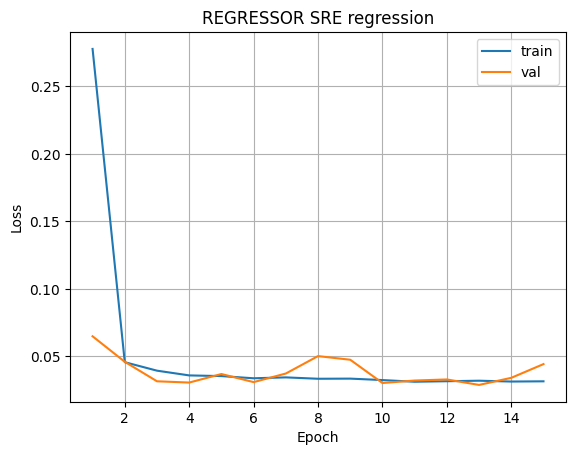

Model checkpoint already exists at %s. Saving to %s instead. ..\models\regressor_huber_random.pt ..\models\regressor_huber_random_v1.pt
Saved model checkpoint to ..\models\regressor_huber_random_v1.pt
Final test loss: 0.028830


In [81]:
model, loss, hist, chkpt = train(
    model_type="regressor",
    epochs = 15,
    lr = 1e-3,
    loss_type = "huber",   # "mse" | "huber"
    batch_size = 64,
    training_mode = "per_family",  # "global" | "per_family"
    family = "random",  # required if training_mode == "per_family"
    target = "sre",
    model_hparams = default_model_hparams,
    train_hparams = default_train_hparams,
    training_data_dir = "../outputs/data",
    allow_overwrite = False,
    save_checkpoint = True,
    save_fig = False,
    show_progress = True,
    show_val_progress = False,
    log_every_n_batches = 5,
    heartbeat_secs = 60.0,
    epoch_time_warning_secs = 500.0,
)

print(f"Final test loss: {loss:.6f}")

In [82]:
preds = create_predictions(
    model_path="../models/regressor_huber_random_v1.pt",
    model_kind="regressor",
    training_scope="family",
    loss_type="huber",
    model_family="random",
    data_dir="../outputs/data",
    data_family="random",
    batch_size=64,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_layers=80,
    plot_qubits=8,
    split_by_family=True,
    show_progress=True,
)

Loading checkpoint: %s models\regressor_model_huber_random.pt
Checkpoint loaded from ../models/regressor_huber_random_v1.pt
Model config: {'node_in_dim': 153, 'global_in_dim': 153, 'gnn_hidden': None, 'gnn_heads': None, 'global_hidden': None, 'reg_hidden': None, 'num_layers': None, 'dropout_rate': None}
Feature config: {'global_feature_variant': 'binned', 'node_feature_backend_variant': None, 'all_gate_keys': ['CNOT_count', 'rx_bin_0', 'rx_bin_1', 'rx_bin_10', 'rx_bin_11', 'rx_bin_12', 'rx_bin_13', 'rx_bin_14', 'rx_bin_15', 'rx_bin_16', 'rx_bin_17', 'rx_bin_18', 'rx_bin_19', 'rx_bin_2', 'rx_bin_20', 'rx_bin_21', 'rx_bin_22', 'rx_bin_23', 'rx_bin_24', 'rx_bin_25', 'rx_bin_26', 'rx_bin_27', 'rx_bin_28', 'rx_bin_29', 'rx_bin_3', 'rx_bin_30', 'rx_bin_31', 'rx_bin_32', 'rx_bin_33', 'rx_bin_34', 'rx_bin_35', 'rx_bin_36', 'rx_bin_37', 'rx_bin_38', 'rx_bin_39', 'rx_bin_4', 'rx_bin_40', 'rx_bin_41', 'rx_bin_42', 'rx_bin_43', 'rx_bin_44', 'rx_bin_45', 'rx_bin_46', 'rx_bin_47', 'rx_bin_48', 'rx_b

RuntimeError: Error(s) in loading state_dict for Regressor:
	size mismatch for net.0.weight: copying a param with shape torch.Size([64, 153]) from checkpoint, the shape in current model is torch.Size([128, 153]).
	size mismatch for net.0.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for net.3.weight: copying a param with shape torch.Size([64, 64]) from checkpoint, the shape in current model is torch.Size([128, 128]).
	size mismatch for net.3.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for net.6.weight: copying a param with shape torch.Size([1, 64]) from checkpoint, the shape in current model is torch.Size([1, 128]).

Using device: cuda
-------- EPOCH 001 --------
Epoch 1/25:  99%|█████████▉| 894/900 [01:00<00:00, 14.66it/s, loss=0.4655, graphs=28640][Heartbeat] Epoch 1 batch 895/900 | loss 0.465480 | elapsed 60.0s | graphs 28640
Training complete (60.4s) | running validation...                                       
Losses | train 0.463452 | val 0.133583 | lr 1.00e-03 | time train=60.4s val=6.0s total=66.4s
-------- EPOCH 002 --------
Epoch 2/25:  99%|█████████▉| 892/900 [01:00<00:00, 14.69it/s, loss=0.1225, graphs=28576][Heartbeat] Epoch 2 batch 893/900 | loss 0.122541 | elapsed 60.0s | graphs 28576
Training complete (60.5s) | running validation...                                       
Losses | train 0.122158 | val 0.076727 | lr 1.00e-03 | time train=60.5s val=6.1s total=66.5s
-------- EPOCH 003 --------
Epoch 3/25:  99%|█████████▉| 892/900 [01:00<00:00, 14.66it/s, loss=0.0990, graphs=28608][Heartbeat] Epoch 3 batch 894/900 | loss 0.098980 | elapsed 60.0s | graphs 28608
Training complete (60.5s) 

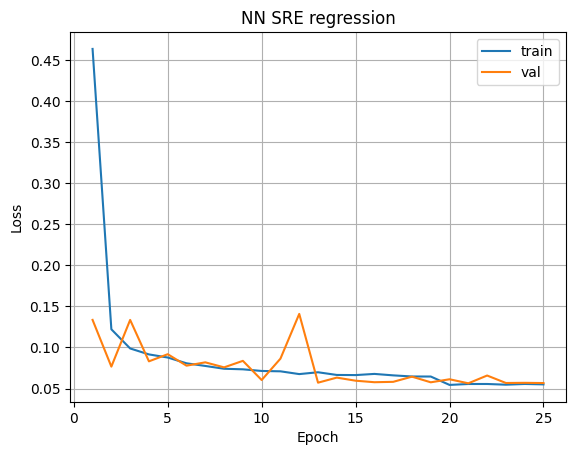

Model checkpoint already exists at %s. Saving to %s instead. ..\models\nn_model_mse_random.pt ..\models\nn_model_mse_random_v1.pt
Saved model checkpoint to %s ..\models\nn_model_mse_random_v1.pt


In [ ]:
default_model_hparams = {
    "hidden_dim": 128,
    "dropout_rate": 0.0,
}

default_train_hparams = {
    "weight_decay": 1e-3,
    "grad_clip": 5.0,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

model, loss, hist, chkpt = train(
    model_type="nn",
    epochs = 15,
    lr = 1e-3,
    loss_type = "huber",   # "mse" | "huber"
    training_mode = "per_family",  # "global" | "per_family"
    family = "random",  # required if training_mode == "per_family"
    target = "sre",
    model_hparams = default_model_hparams,
    train_hparams = default_train_hparams,
    training_data_dir = "../outputs/data",
    allow_overwrite = False,
    save_checkpoint = False,
    save_fig = False,
    show_progress = True,
    show_val_progress = False,
    log_every_n_batches = 10,
    heartbeat_secs = 60.0,
    epoch_time_warning_secs = 500.0,
)

print(f"Final test loss: {loss:.6f}")

## Parameter search

In [ ]:
def objective_GNN(trial: optuna.Trial):
    model_type = "gnn"
    training_mode = "per_family"
    family = "random"

    train_hparams = {
        "weight_decay": trial.suggest_float(
            "weight_decay", 1e-5, 1e-2, log=True,
        ),
        "grad_clip": trial.suggest_float(
            "grad_clip", 1e-2, 1e2, log=True,
        ),
        "early_stopping_patience": 20,
        "early_stopping_min_delta": 1e-5,
    }

    model_hparams = {
        "gnn_hidden": trial.suggest_categorical("gnn_hidden", [16, 32, 64, 128]),
        "gnn_heads": trial.suggest_categorical("gnn_heads", [2, 4, 8]),
        "global_hidden": trial.suggest_categorical("global_hidden", [16, 32, 64, 128]),
        "reg_hidden": trial.suggest_categorical("reg_hidden", [16, 32, 64, 128]),
        "num_layers": trial.suggest_int("num_layers", 2, 6),
        "dropout_rate": trial.suggest_float("dropout_rate", 0.0, 0.5),
    }
    _, test_loss, _, _ = train(
        model_type=model_type,
        epochs=25,
        lr=trial.suggest_float("lr", 1e-5, 3e-3, log=True),
        loss_type=trial.suggest_categorical("loss_type", ["mse", "huber"]),
        batch_size=trial.suggest_categorical("batch_size", [16, 32, 64, 128]),
        training_mode=training_mode,
        family=family,
        model_hparams=model_hparams,
        train_hparams=train_hparams,
        save_checkpoint=False,
        save_fig=False,
        show_progress=False,
        show_val_progress=False,
    )

    return test_loss

def objective_NN(trial: optuna.Trial):
    model_type = "nn"
    training_mode = "per_family"
    family = "random"

    train_hparams = {
        "weight_decay": trial.suggest_float(
            "weight_decay", 1e-5, 1e-2, log=True,
        ),
        "grad_clip": trial.suggest_float(
            "grad_clip", 1e-2, 1e2, log=True,
        ),
        "early_stopping_patience": 20,
        "early_stopping_min_delta": 1e-5,
    }

    model_hparams = {
        "nn_hidden": trial.suggest_categorical("nn_hidden", [32, 64, 128, 256]),
        "dropout_rate": trial.suggest_float("dropout_rate", 0.0, 0.5),
    }
    _, test_loss, _, _ = train(
        model_type=model_type,
        epochs=25,
        lr=trial.suggest_float("lr", 1e-5, 3e-3, log=True),
        loss_type=trial.suggest_categorical("loss_type", ["mse", "huber"]),
        batch_size=trial.suggest_categorical("batch_size", [16, 32, 64, 128]),
        training_mode=training_mode,
        family=family,
        model_hparams=model_hparams,
        train_hparams=train_hparams,
        save_checkpoint=False,
        save_fig=False,
        show_progress=False,
        show_val_progress=False,
    )

    return test_loss



In [19]:
study = optuna.create_study(
    direction="minimize",
    storage="sqlite:///nn_optuna_study.db",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5, n_startup_trials=10),
)
study.optimize(objective_GNN, n_trials=5)

print(study.best_trial.value)
print(study.best_trial.params)

[I 2026-05-01 16:30:46,217] A new study created in RDB with name: no-name-9c40cd1f-fc00-47c2-8f1c-7e8f545b8a38


Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=mse
Training configuration done.
Found 40000 data paths.
Data paths collected.
Building loaders and model for model_type=gnn...
Loaders and model built.
Starting training...
Using device: cuda
-------- EPOCH 001 --------
[Heartbeat] Epoch 1 batch 593/900 | loss 4.505518 | elapsed 60.1s | graphs 18976
Training complete (90.5s) | running validation...
Losses | train 3.494749 | val 0.565136 | lr 5.27e-05 | time train=90.5s val=9.2s total=99.6s
-------- EPOCH 002 --------
[Heartbeat] Epoch 2 batch 583/900 | loss 0.633587 | elapsed 60.0s | graphs 18656
Training complete (93.3s) | running validation...
Losses | train 0.580061 | val 0.302716 | lr 5.27e-05 | time train=93.3s val=9.1s total=102.3s
-------- EPOCH 003 --------
[Heartbeat] Epoch 3 batch 559/900 | loss 0.428338 | elapsed 60.0s | graphs 17888
Training complete (94.8s) | running validation...
Losses | train 0.416094 | val 0.227994 | lr 5.27e-05 

[I 2026-05-01 17:15:45,069] Trial 0 finished with value: 0.11881103004515171 and parameters: {'weight_decay': 0.0001329291894316216, 'grad_clip': 63.512210106407046, 'gnn_hidden': 16, 'gnn_heads': 4, 'global_hidden': 64, 'reg_hidden': 128, 'num_layers': 4, 'dropout_rate': 0.21597250932105788, 'lr': 5.265139631677751e-05, 'loss_type': 'mse'}. Best is trial 0 with value: 0.11881103004515171.


Training complete.
Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=mse
Training configuration done.
Found 40000 data paths.
Data paths collected.
Building loaders and model for model_type=gnn...
Loaders and model built.
Starting training...
Using device: cuda
-------- EPOCH 001 --------
[Heartbeat] Epoch 1 batch 601/900 | loss 12.534193 | elapsed 60.0s | graphs 19232
Training complete (90.6s) | running validation...
Losses | train 10.776980 | val 4.232734 | lr 1.22e-05 | time train=90.6s val=9.5s total=100.1s
-------- EPOCH 002 --------
[Heartbeat] Epoch 2 batch 599/900 | loss 3.557689 | elapsed 60.0s | graphs 19168
Training complete (90.2s) | running validation...
Losses | train 3.379071 | val 1.761492 | lr 1.22e-05 | time train=90.2s val=9.7s total=99.9s
-------- EPOCH 003 --------
[Heartbeat] Epoch 3 batch 595/900 | loss 2.763825 | elapsed 60.1s | graphs 19040
Training complete (90.6s) | running validation...
Losses | train 2.734208 | val 1.

[I 2026-05-01 17:58:39,034] Trial 1 finished with value: 0.2071226115077734 and parameters: {'weight_decay': 0.00012562773503807024, 'grad_clip': 0.6672367170464207, 'gnn_hidden': 16, 'gnn_heads': 4, 'global_hidden': 64, 'reg_hidden': 64, 'num_layers': 2, 'dropout_rate': 0.2475884550556351, 'lr': 1.216702881459345e-05, 'loss_type': 'mse'}. Best is trial 0 with value: 0.11881103004515171.


...

Training complete.
Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=l1
Training configuration done.
Found 40000 data paths.
Data paths collected.
Building loaders and model for model_type=gnn...
Loaders and model built.
Starting training...
Using device: cuda
-------- EPOCH 001 --------
[Heartbeat] Epoch 1 batch 498/900 | loss 1.087343 | elapsed 60.1s | graphs 15936
Training complete (108.5s) | running validation...
Losses | train 0.974723 | val 1.811333 | lr 1.58e-03 | time train=108.5s val=10.8s total=119.2s
-------- EPOCH 002 --------
[Heartbeat] Epoch 2 batch 499/900 | loss 0.754555 | elapsed 60.1s | graphs 15968
Training complete (108.4s) | running validation...
Losses | train 0.706185 | val 1.607383 | lr 1.58e-03 | time train=108.4s val=10.7s total=119.2s
-------- EPOCH 003 --------
[Heartbeat] Epoch 3 batch 498/900 | loss 0.608812 | elapsed 60.1s | graphs 15936
Training complete (108.6s) | running validation...
Losses | train 0.598325 | v

[I 2026-05-01 19:32:42,540] Trial 3 finished with value: 1.3887938635349273 and parameters: {'weight_decay': 0.009133995846860976, 'grad_clip': 12.273800987852969, 'gnn_hidden': 64, 'gnn_heads': 4, 'global_hidden': 64, 'reg_hidden': 16, 'num_layers': 5, 'dropout_rate': 0.31877873567760656, 'lr': 0.0015766436357943082, 'loss_type': 'l1'}. Best is trial 2 with value: 0.03925013052299619.


Training complete.
Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=mse
Training configuration done.
Found 40000 data paths.
Data paths collected.
Building loaders and model for model_type=gnn...
Loaders and model built.
Starting training...
Using device: cuda
-------- EPOCH 001 --------
[Heartbeat] Epoch 1 batch 608/900 | loss 5.214910 | elapsed 60.0s | graphs 19456
Training complete (89.0s) | running validation...
Losses | train 4.129588 | val 1.263374 | lr 2.51e-05 | time train=89.0s val=9.3s total=98.2s
-------- EPOCH 002 --------
[Heartbeat] Epoch 2 batch 610/900 | loss 1.539631 | elapsed 60.1s | graphs 19520
Training complete (88.5s) | running validation...
Losses | train 1.486842 | val 0.951524 | lr 2.51e-05 | time train=88.5s val=9.2s total=97.7s
-------- EPOCH 003 --------
[Heartbeat] Epoch 3 batch 607/900 | loss 1.266145 | elapsed 60.0s | graphs 19424
Training complete (88.9s) | running validation...
Losses | train 1.231467 | val 0.779

[I 2026-05-01 20:15:44,872] Trial 4 finished with value: 0.08006068940460682 and parameters: {'weight_decay': 0.0019158219548093154, 'grad_clip': 1.7583640270008525, 'gnn_hidden': 16, 'gnn_heads': 4, 'global_hidden': 128, 'reg_hidden': 64, 'num_layers': 2, 'dropout_rate': 0.144875726456884, 'lr': 2.5082145184394066e-05, 'loss_type': 'mse'}. Best is trial 2 with value: 0.03925013052299619.


Training complete.
0.03925013052299619
{'weight_decay': 8.612579192594876e-05, 'grad_clip': 1.2030178871154673, 'gnn_hidden': 64, 'gnn_heads': 2, 'global_hidden': 16, 'reg_hidden': 128, 'num_layers': 3, 'dropout_rate': 0.14046725484369038, 'lr': 0.00022096526145513835, 'loss_type': 'huber'}


In [17]:
study = optuna.create_study(
    direction="minimize",
    storage="sqlite:///nn_optuna_study.db",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5, n_startup_trials=10),
)
study.optimize(objective_NN, n_trials=2)

print(study.best_trial.value)
print(study.best_trial.params)

[I 2026-05-01 13:21:02,455] A new study created in RDB with name: no-name-84536598-bd6d-4c2b-83cd-dbc925cd2b4e


Starting training | model_type=nn | training_mode=per_family | family=random | loss_type=huber
Training configuration done.
Found 40000 data paths.
Data paths collected.
Building loaders and model for model_type=nn...
Loaders and model built.
Starting training...
Using device: cuda
-------- EPOCH 001 --------
[Heartbeat] Epoch 1 batch 867/900 | loss 0.239425 | elapsed 60.0s | graphs 27744
Training complete (62.5s) | running validation...
Losses | train 0.234336 | val 0.048384 | lr 1.40e-03 | time train=62.5s val=7.4s total=69.9s
-------- EPOCH 002 --------
[Heartbeat] Epoch 2 batch 804/900 | loss 0.090358 | elapsed 60.0s | graphs 25728
Training complete (66.1s) | running validation...
Losses | train 0.089163 | val 0.078420 | lr 1.40e-03 | time train=66.1s val=6.2s total=72.3s
-------- EPOCH 003 --------
[Heartbeat] Epoch 3 batch 878/900 | loss 0.073375 | elapsed 60.1s | graphs 28096
Training complete (61.6s) | running validation...
Losses | train 0.073111 | val 0.050860 | lr 1.40e-03 |

[I 2026-05-01 13:52:08,652] Trial 0 finished with value: 0.03250169923529029 and parameters: {'weight_decay': 0.0001329291894316216, 'grad_clip': 63.512210106407046, 'nn_hidden': 32, 'dropout_rate': 0.02904180608409973, 'lr': 0.0013983740016490966, 'loss_type': 'huber'}. Best is trial 0 with value: 0.03250169923529029.


Training complete.
Starting training | model_type=nn | training_mode=per_family | family=random | loss_type=huber
Training configuration done.
Found 40000 data paths.
Data paths collected.
Building loaders and model for model_type=nn...
Loaders and model built.
Starting training...
Using device: cuda
-------- EPOCH 001 --------
[Heartbeat] Epoch 1 batch 777/900 | loss 0.743764 | elapsed 60.0s | graphs 24864
Training complete (69.1s) | running validation...
Losses | train 0.719049 | val 0.407034 | lr 1.17e-04 | time train=69.1s val=8.7s total=77.8s
-------- EPOCH 002 --------
[Heartbeat] Epoch 2 batch 765/900 | loss 0.490252 | elapsed 60.1s | graphs 24480
Training complete (70.5s) | running validation...
Losses | train 0.483789 | val 0.410636 | lr 1.17e-04 | time train=70.5s val=7.9s total=78.4s
-------- EPOCH 003 --------
[Heartbeat] Epoch 3 batch 772/900 | loss 0.407198 | elapsed 60.0s | graphs 24704
Training complete (69.9s) | running validation...
Losses | train 0.404468 | val 0.341

[I 2026-05-01 14:25:17,149] Trial 1 finished with value: 0.2980653802156448 and parameters: {'weight_decay': 0.008123245085588688, 'grad_clip': 21.368329072358772, 'nn_hidden': 256, 'dropout_rate': 0.2623782158161189, 'lr': 0.00011748439548007026, 'loss_type': 'huber'}. Best is trial 0 with value: 0.03250169923529029.


Training complete.
0.03250169923529029
{'weight_decay': 0.0001329291894316216, 'grad_clip': 63.512210106407046, 'nn_hidden': 32, 'dropout_rate': 0.02904180608409973, 'lr': 0.0013983740016490966, 'loss_type': 'huber'}


# Predictions

In [66]:
gnn_model_path = "../models/GNN_model_huber_random_v2.pt"
nn_model_path_1 = "../models/nn_model_mse_random_v1.pt"
nn_model_path_2 = "../models/nn_model_huber_random_v3.pt"

In [67]:
model_kind: str = "nn"
training_scope: str = "family"
loss_type: str = "huber"
model_family: str | None = "random" #"clifford"
dataset_root: str = "../outputs/data"
dataset_family: str | None = "random"
batch_size: int = 32
global_feature_variant: str = "binned"
node_feature_backend_variant: str | None = None
plot_n_layers: int | None = 80
plot_n_qubits: int | None = 16
split_by_family: bool = True
show_progress: bool = True

In [68]:
ckpt_path = checkpoint_path(model_kind, training_scope, model_family, loss_type)
print("Loading checkpoint: %s", ckpt_path)
output_csv = f"../outputs/figures/predictions/{training_scope}/{model_kind}_predictions_{model_family or 'global'}2.csv"


Loading checkpoint: %s models\nn_model_huber_random.pt


In [69]:
state_dict, model_config, feature_config = load_checkpoint(nn_model_path_2)

model = build_model(model_kind, model_config)
model.load_state_dict(state_dict, strict=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [70]:
pt_paths = collect_prediction_paths(dataset_root, dataset_family)
if not pt_paths:
    raise RuntimeError("No prediction .pt files found.")

print("Found %d prediction files", len(pt_paths))

dataset = build_prediction_dataset(
        pt_paths,
        global_feature_variant=feature_config.get("global_feature_variant", global_feature_variant),
        node_feature_backend_variant=feature_config.get("node_feature_backend_variant", node_feature_backend_variant),
        fixed_all_gate_keys=feature_config.get("all_gate_keys"),
    )

loader = build_loader(
        model_kind,
        dataset,
        batch_size=batch_size,
        target_node_dim=model_config.get("node_in_dim"),
        target_global_dim=model_config.get("global_in_dim"),
    )

Found %d prediction files 75000


In [71]:
rows = predict(
        model,
        loader,
        model_kind=model_kind,
        device=device,
        show_progress=show_progress,
    )
save_predictions_csv(rows, output_csv)

Predicting (nn): 100%|██████████| 2344/2344 [01:27<00:00, 26.88batch/s]


WindowsPath('../outputs/figures/predictions/family/nn_predictions_random2.csv')

In [72]:
print(rows[:5])

[{'cid': 'random_Q10_L100_S1007406471', 'family': 'random', 'seed': 1007406471, 'n_qubits': 10, 'n_layers': 100, 'target': 8.00131607055664, 'prediction': 3.195868492126465, 'error': 4.805447578430176}, {'cid': 'random_Q10_L100_S1042474350', 'family': 'random', 'seed': 1042474350, 'n_qubits': 10, 'n_layers': 100, 'target': 7.998676776885986, 'prediction': 0.0, 'error': 7.998676776885986}, {'cid': 'random_Q10_L100_S1043314352', 'family': 'random', 'seed': 1043314352, 'n_qubits': 10, 'n_layers': 100, 'target': 8.00510025024414, 'prediction': 6.049405470490235e-41, 'error': 8.00510025024414}, {'cid': 'random_Q10_L100_S1070012488', 'family': 'random', 'seed': 1070012488, 'n_qubits': 10, 'n_layers': 100, 'target': 8.00312328338623, 'prediction': 7.2783442237031e-42, 'error': 8.00312328338623}, {'cid': 'random_Q10_L100_S1076020488', 'family': 'random', 'seed': 1076020488, 'n_qubits': 10, 'n_layers': 100, 'target': 8.001457214355469, 'prediction': 3.8079655170440674, 'error': 4.19349169731140

In [73]:
import pandas as pd

import torch

def extract_scalar(x):
    if isinstance(x, torch.Tensor):
        return x.item()
    if isinstance(x, str):
        # handle "tensor([10])"
        if "tensor" in x:
            return int(x.split("[")[1].split("]")[0])
        return int(x)
    return int(x)


df_gnn = pd.read_csv("../outputs/figures/predictions/family/gnn_predictions_random.csv")
df_nn = pd.read_csv("../outputs/figures/predictions/family/nn_predictions_random.csv")
df_nn2 = pd.read_csv("../outputs/figures/predictions/family/nn_predictions_random2.csv")

In [60]:
df_gnn["n_qubits"] = df_gnn["n_qubits"].apply(extract_scalar)
df_gnn["n_layers"] = df_gnn["n_layers"].apply(extract_scalar)
df_gnn["seed"] = df_gnn["seed"].apply(extract_scalar)

In [74]:
print(df_nn2.head())

                           cid  family        seed  n_qubits  n_layers  \
0  random_Q10_L100_S1007406471  random  1007406471        10       100   
1  random_Q10_L100_S1042474350  random  1042474350        10       100   
2  random_Q10_L100_S1043314352  random  1043314352        10       100   
3  random_Q10_L100_S1070012488  random  1070012488        10       100   
4  random_Q10_L100_S1076020488  random  1076020488        10       100   

     target    prediction     error  
0  8.001316  3.195868e+00  4.805448  
1  7.998677  0.000000e+00  7.998677  
2  8.005100  6.049405e-41  8.005100  
3  8.003123  7.278344e-42  8.003123  
4  8.001457  3.807966e+00  4.193492  


In [76]:
corr = df_nn2["target"].corr(df_nn2["prediction"])
print(f"Correlation between target and prediction: {corr:.4f}")

Correlation between target and prediction: 0.1854


In [78]:
res_10q_40l = df_nn2[(df_nn2["n_qubits"] == 10) & (df_nn2["n_layers"] == 40)]

In [79]:
print(res_10q_40l)

                             cid  family        seed  n_qubits  n_layers  \
4250  random_Q10_L40_S1003980808  random  1003980808        10        40   
4251  random_Q10_L40_S1029409470  random  1029409470        10        40   
4252  random_Q10_L40_S1042107651  random  1042107651        10        40   
4253   random_Q10_L40_S104860666  random   104860666        10        40   
4254  random_Q10_L40_S1050204211  random  1050204211        10        40   
...                          ...     ...         ...       ...       ...   
4495   random_Q10_L40_S954347189  random   954347189        10        40   
4496   random_Q10_L40_S961956443  random   961956443        10        40   
4497   random_Q10_L40_S962269546  random   962269546        10        40   
4498   random_Q10_L40_S983681243  random   983681243        10        40   
4499   random_Q10_L40_S984166392  random   984166392        10        40   

        target    prediction     error  
4250  7.893902  2.212649e-18  7.893902  
4251 

In [81]:
corr = res_10q_40l["target"].corr(res_10q_40l["prediction"])
print(f"Correlation between target and prediction: {corr:.4f}")

Correlation between target and prediction: 0.0163
